In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Affichage plus lisible dans le notebook
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Charger les donnees (fichier CSV separe par ;)
file_path = "bank-full.csv"
df = pd.read_csv(file_path, sep=';')

print("Apercu du dataset:")
display(df.head())

print(f"Dimensions: {df.shape[0]} lignes x {df.shape[1]} colonnes")

print("\nTypes des variables:")
display(df.dtypes.to_frame("dtype"))

print("\nValeurs manquantes (nombre et pourcentage):")
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
missing_table = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct
}).sort_values("missing_count", ascending=False)
display(missing_table)

print(f"\nNombre total de valeurs manquantes: {int(missing_count.sum())}")

print("\nVerification des valeurs 'unknown' (colonnes categorielles):")
cat_cols = df.select_dtypes(include="object").columns
unknown_count = (df[cat_cols] == "unknown").sum()
unknown_pct = (unknown_count / len(df) * 100).round(2)
unknown_table = pd.DataFrame({
    "unknown_count": unknown_count,
    "unknown_pct": unknown_pct
}).sort_values("unknown_count", ascending=False)
display(unknown_table)
print(f"\nNombre total de valeurs 'unknown': {int(unknown_count.sum())}")

Apercu du dataset:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


Dimensions: 45211 lignes x 17 colonnes

Types des variables:


,dtype
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64



Valeurs manquantes (nombre et pourcentage):


,missing_count,missing_pct
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day,0,0.0



Nombre total de valeurs manquantes: 0

Verification des valeurs 'unknown' (colonnes categorielles):


,unknown_count,unknown_pct
poutcome,36959,81.75
contact,13020,28.80
education,1857,4.11
job,288,0.64
marital,0,0.00
default,0,0.00
loan,0,0.00
housing,0,0.00
month,0,0.00
y,0,0.00



Nombre total de valeurs 'unknown': 52124


In [2]:
# Traitement des 'unknown': contact supprime, education/job imputes par le mode, poutcome garde tel quel
df = df.drop(columns=["contact"])
for col in ["education", "job"]:
    mode_val = df.loc[df[col] != "unknown", col].mode().iloc[0]
    df[col] = df[col].replace("unknown", mode_val)
print("\nTraitement applique")


Traitement applique


Nombre de doublons exacts: 0

Rapport outliers (methode IQR):


,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,pct_outliers
previous,0.0,0.0,0.0,0.0,0.0,8257.0,18.26
pdays,-1.0,-1.0,0.0,-1.0,-1.0,8257.0,18.26
balance,72.0,1428.0,1356.0,-1962.0,3462.0,4729.0,10.46
duration,103.0,319.0,216.0,-221.0,643.0,3235.0,7.16
campaign,1.0,3.0,2.0,-2.0,6.0,3064.0,6.78
age,33.0,48.0,15.0,10.5,70.5,487.0,1.08
day,8.0,21.0,13.0,-11.5,40.5,0.0,0.00


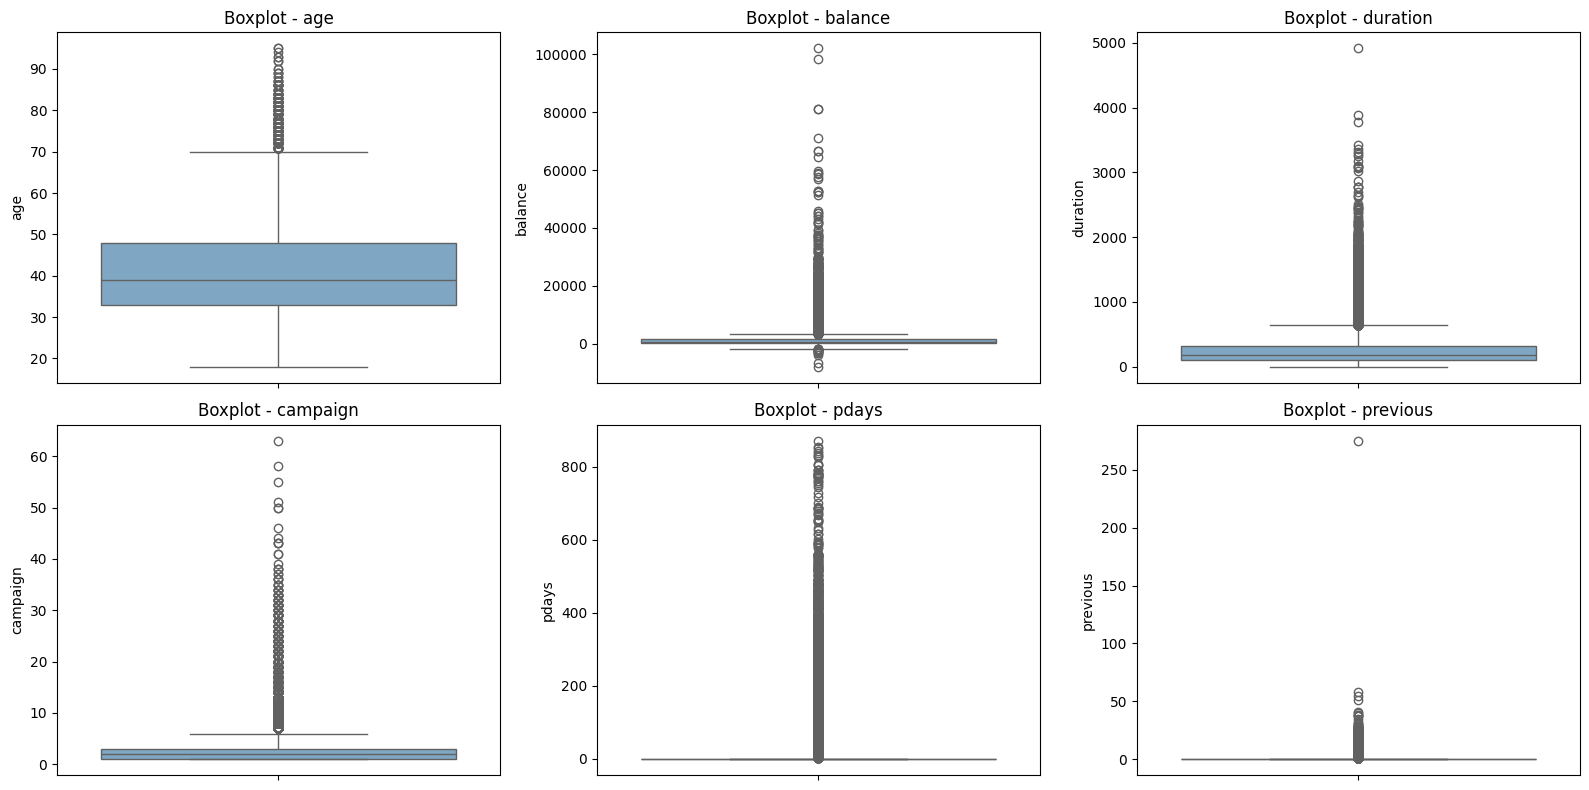

In [3]:
# 1) Doublons
n_duplicates = df.duplicated().sum()
print(f"Nombre de doublons exacts: {n_duplicates}")

# 2) Outliers (IQR) sur variables numeriques
num_cols = df.select_dtypes(include=["number"]).columns.tolist()

def iqr_outlier_count(series: pd.Series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((series < lower) | (series > upper)).sum()
    return pd.Series({
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "n_outliers": int(outliers),
        "pct_outliers": round(outliers / len(series) * 100, 2)
    })

outlier_report = df[num_cols].apply(iqr_outlier_count).T.sort_values("pct_outliers", ascending=False)
print("\nRapport outliers (methode IQR):")
display(outlier_report)

# 3) Boxplots pour visualiser les distributions et valeurs extremes
plot_cols = ["age", "balance", "duration", "campaign", "pdays", "previous"]
plot_cols = [c for c in plot_cols if c in df.columns]

n_cols = 3
n_rows = int(np.ceil(len(plot_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(plot_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="#74a9cf")
    axes[i].set_title(f"Boxplot - {col}")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# 4) Coherence des modalites / regles metier simples
coherence_checks = {
    "age_out_of_range_[18,100]": (~df["age"].between(18, 100)).sum(),
    "duration_negative": (df["duration"] < 0).sum(),
    "campaign_lt_1": (df["campaign"] < 1).sum(),
    "day_out_of_range_[1,31]": (~df["day"].between(1, 31)).sum(),
    "previous_negative": (df["previous"] < 0).sum(),
    "target_not_yes_no": (~df["y"].isin(["yes", "no"])).sum()
}
if "pdays" in df.columns:
    coherence_checks["pdays_lt_-1"] = (df["pdays"] < -1).sum()



In [4]:
# 1.4 Description des variables (toutes les colonnes)

num_cols_all = df.select_dtypes(include=["number"]).columns.tolist()
cat_cols_all = df.select_dtypes(include=["object"]).columns.tolist()

var_desc = pd.DataFrame({
    "variable": df.columns,
    "type": ["Numerique" if c in num_cols_all else "Categorielle" for c in df.columns],
    "n_unique": [df[c].nunique(dropna=False) for c in df.columns],
})

print("Description globale de toutes les variables:")
display(var_desc)

# Resume statistique rapide pour interpretation
print("\nResume des variables numeriques:")
display(df[num_cols_all].describe().T)

# Les modelité des variables catégorielle
cat_cols = cat_cols_all.copy()

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(f"Modalites ({df[col].nunique()}): {sorted(df[col].dropna().unique().tolist())}")

cat_summary = pd.DataFrame({
    "n_modalites": df[cat_cols].nunique(),
    "modalite_plus_frequente": [df[c].mode(dropna=False)[0] for c in cat_cols],
    "freq_modalite_plus_frequente": [df[c].value_counts(dropna=False).iloc[0] for c in cat_cols]
}).sort_values("n_modalites", ascending=False)

print("\nResume des variables categorielles:")
display(cat_summary)

print("\nRepartition de la variable cible y:")
display(df["y"].value_counts(dropna=False).to_frame("count"))
display((df["y"].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("pct"))

Description globale de toutes les variables:


,variable,type,n_unique
0,age,Numerique,77
1,job,Categorielle,11
2,marital,Categorielle,3
3,education,Categorielle,3
4,default,Categorielle,2
5,balance,Numerique,7168
6,housing,Categorielle,2
7,loan,Categorielle,2
8,day,Numerique,31
9,month,Categorielle,12



Resume des variables numeriques:


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0



--- job ---
Modalites (11): ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed']

--- marital ---
Modalites (3): ['divorced', 'married', 'single']

--- education ---
Modalites (3): ['primary', 'secondary', 'tertiary']

--- default ---
Modalites (2): ['no', 'yes']

--- housing ---
Modalites (2): ['no', 'yes']

--- loan ---
Modalites (2): ['no', 'yes']

--- month ---
Modalites (12): ['apr', 'aug', 'dec', 'feb', 'jan', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']

--- poutcome ---
Modalites (4): ['failure', 'other', 'success', 'unknown']

--- y ---
Modalites (2): ['no', 'yes']

Resume des variables categorielles:


,n_modalites,modalite_plus_frequente,freq_modalite_plus_frequente
month,12,may,13766
job,11,blue-collar,10020
poutcome,4,unknown,36959
marital,3,married,27214
education,3,secondary,25059
housing,2,yes,25130
default,2,no,44396
loan,2,no,37967
y,2,no,39922



Repartition de la variable cible y:


,count
y,
no,39922
yes,5289


,pct
y,
no,88.3
yes,11.7


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_1648\3388175917.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="y", palette="Set2")


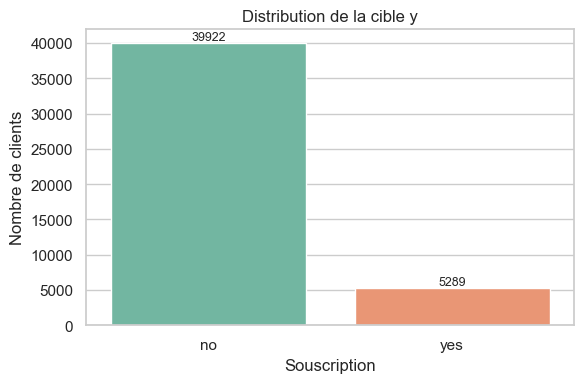

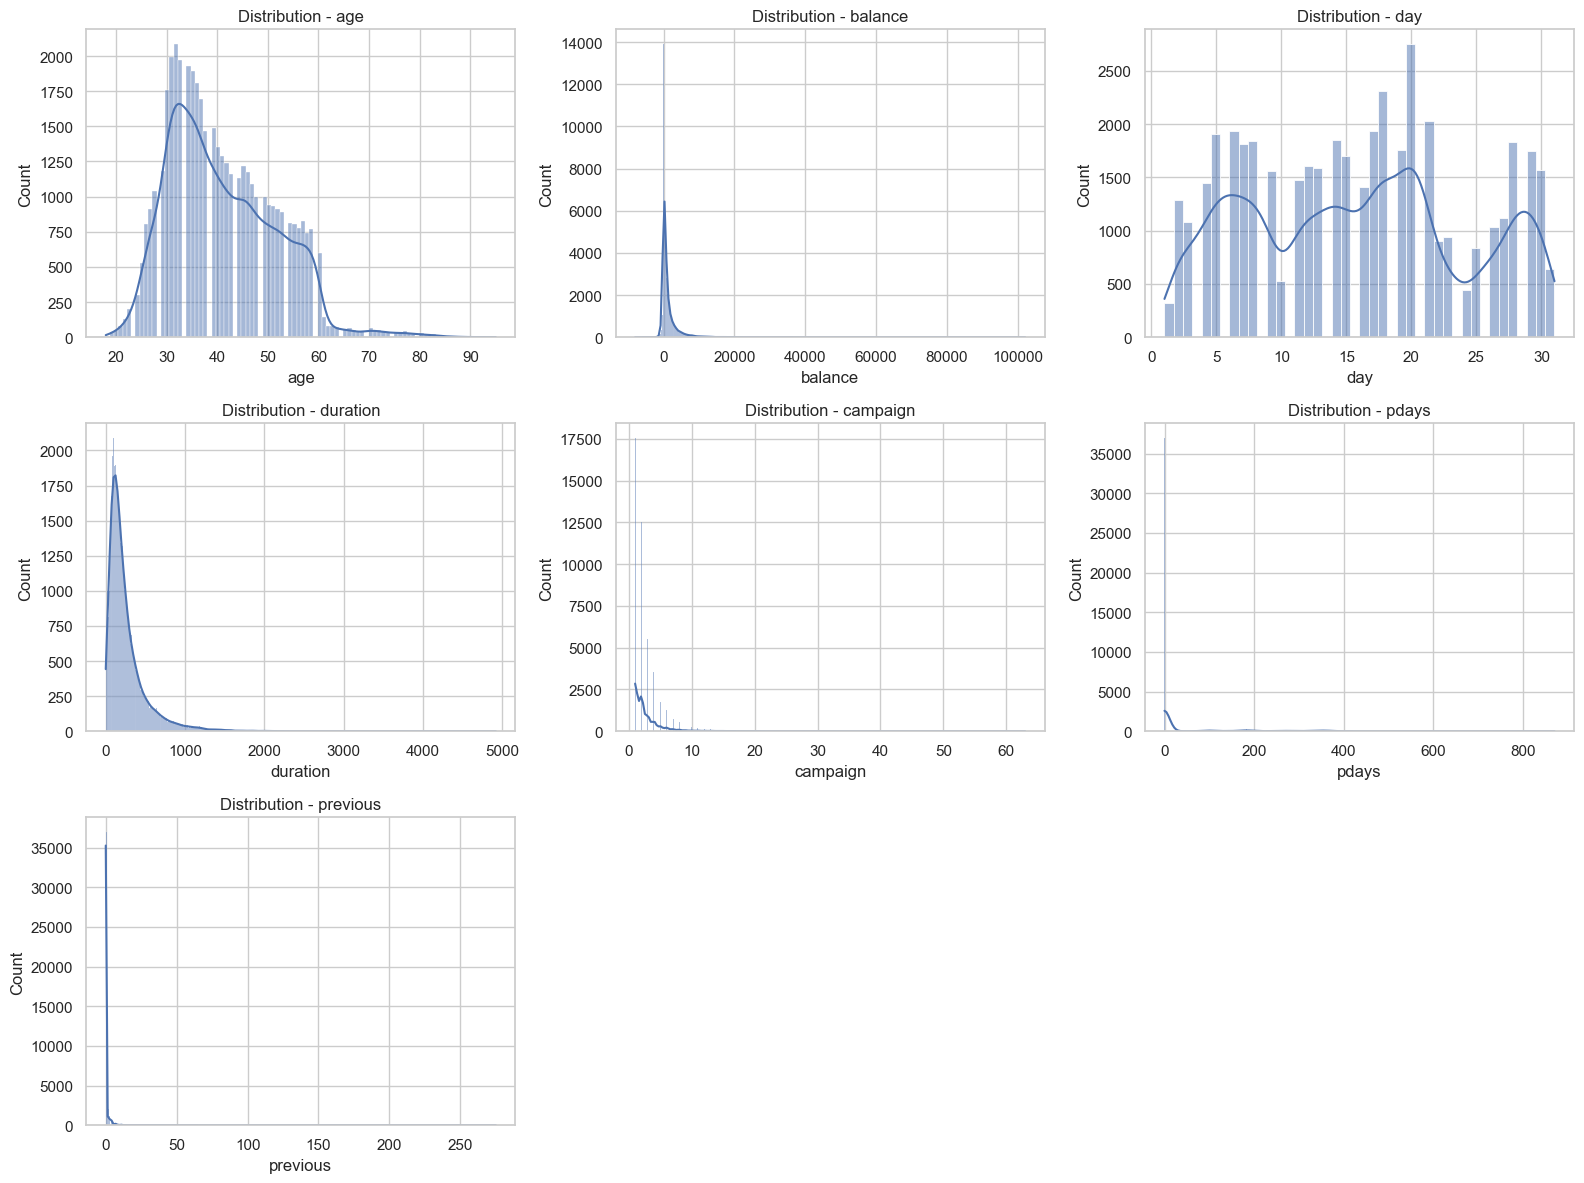

In [5]:
# 2.2 Visualisations principales (toutes les colonnes)

sns.set_theme(style="whitegrid")

# 1) Repartition de la cible
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="y", palette="Set2")
ax.set_title("Distribution de la cible y")
ax.set_xlabel("Souscription")
ax.set_ylabel("Nombre de clients")
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9,
    )
plt.tight_layout()
plt.show()

# 2) Histograms des variables numeriques (toutes)
num_cols_all = [c for c in df.select_dtypes(include=["number"]).columns if c != "y_bin"]
n_cols = 3
n_rows = int(np.ceil(len(num_cols_all) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(num_cols_all):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"Distribution - {col}")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


Taux de souscription par job:


,job,n_clients,taux_souscription
8,student,938,28.68
5,retired,2264,22.79
10,unemployed,1303,15.50
4,management,9458,13.76
0,admin.,5171,12.20
6,self-employed,1579,11.84
9,technician,7597,11.06
7,services,4154,8.88
3,housemaid,1240,8.79
2,entrepreneur,1487,8.27


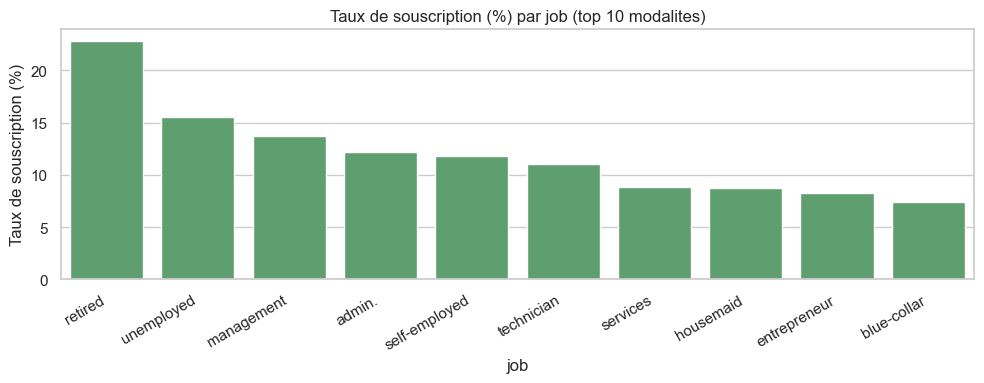


Taux de souscription par marital:


,marital,n_clients,taux_souscription
2,single,12790,14.95
0,divorced,5207,11.95
1,married,27214,10.12


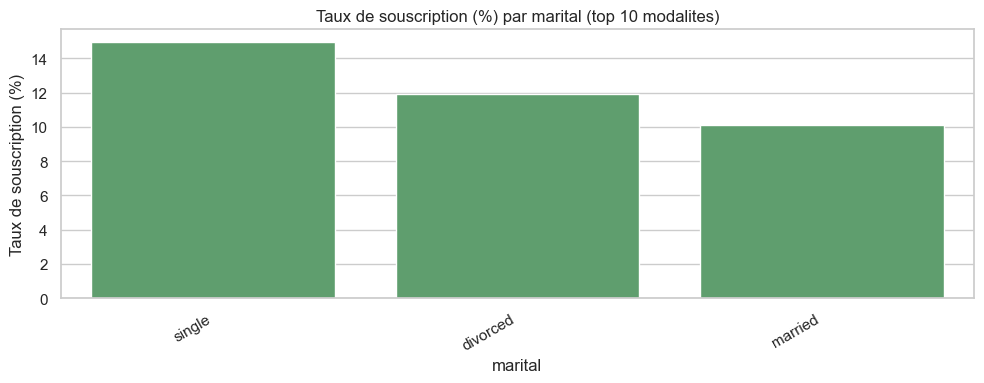


Taux de souscription par education:


,education,n_clients,taux_souscription
2,tertiary,13301,15.01
1,secondary,25059,10.78
0,primary,6851,8.63


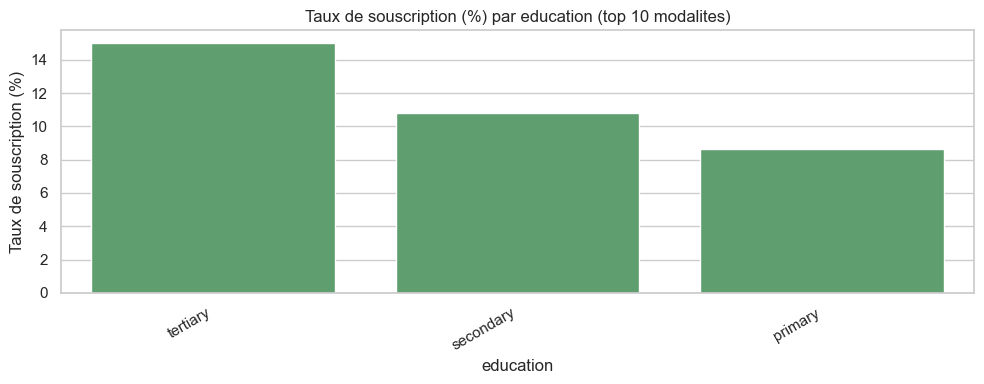


Taux de souscription par default:


,default,n_clients,taux_souscription
0,no,44396,11.80
1,yes,815,6.38


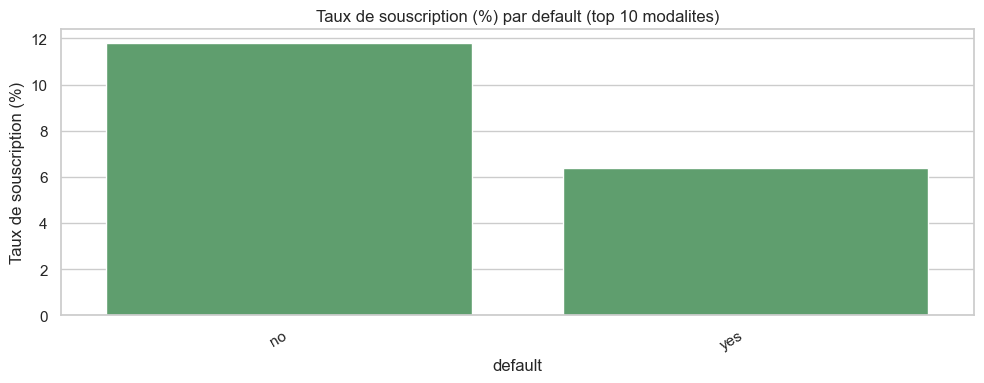


Taux de souscription par housing:


,housing,n_clients,taux_souscription
0,no,20081,16.7
1,yes,25130,7.7


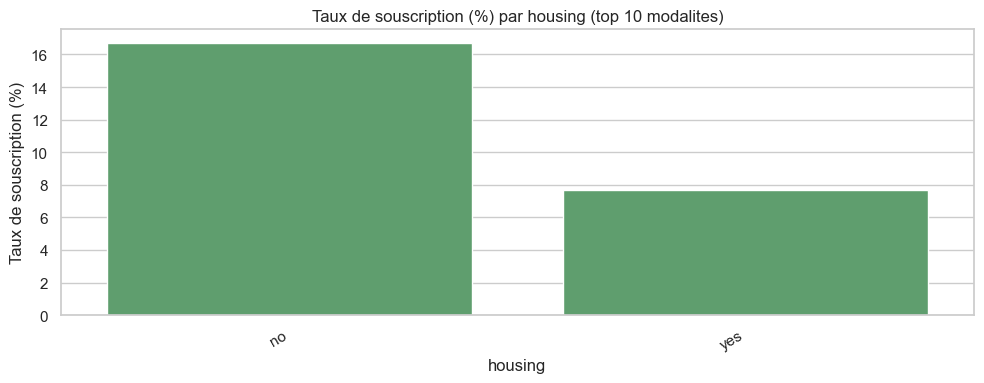


Taux de souscription par loan:


,loan,n_clients,taux_souscription
0,no,37967,12.66
1,yes,7244,6.68


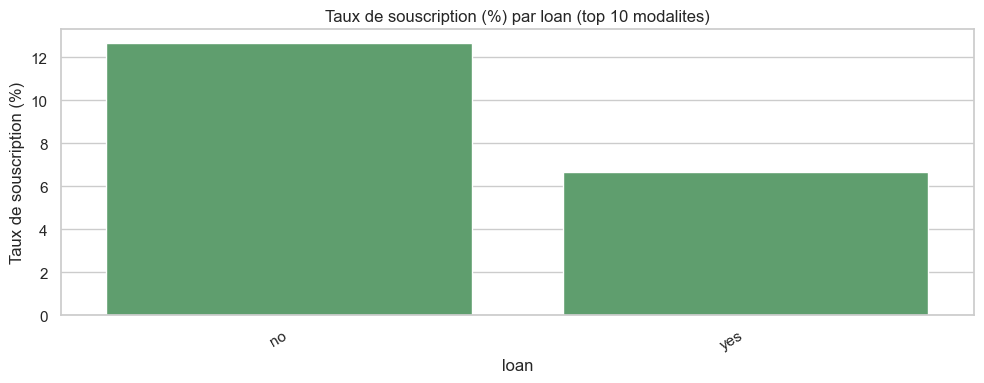


Taux de souscription par month:


,month,n_clients,taux_souscription
7,mar,477,51.99
2,dec,214,46.73
11,sep,579,46.46
10,oct,738,43.77
0,apr,2932,19.68
3,feb,2649,16.65
1,aug,6247,11.01
6,jun,5341,10.22
9,nov,3970,10.15
4,jan,1403,10.12


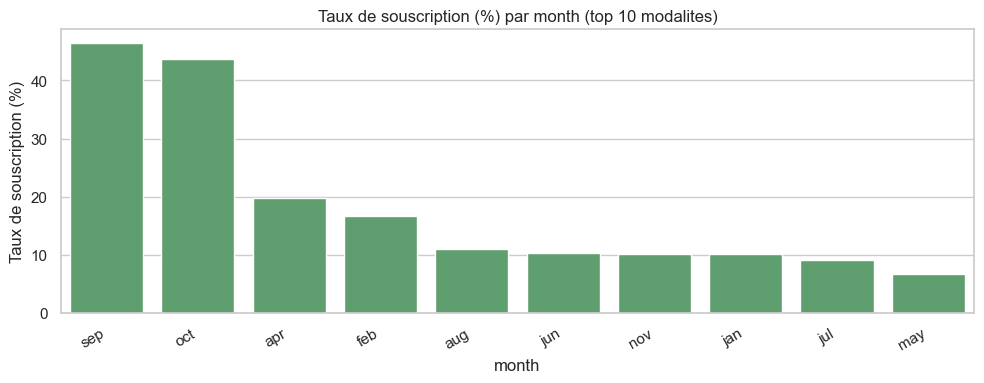


Taux de souscription par poutcome:


,poutcome,n_clients,taux_souscription
2,success,1511,64.73
1,other,1840,16.68
0,failure,4901,12.61
3,unknown,36959,9.16


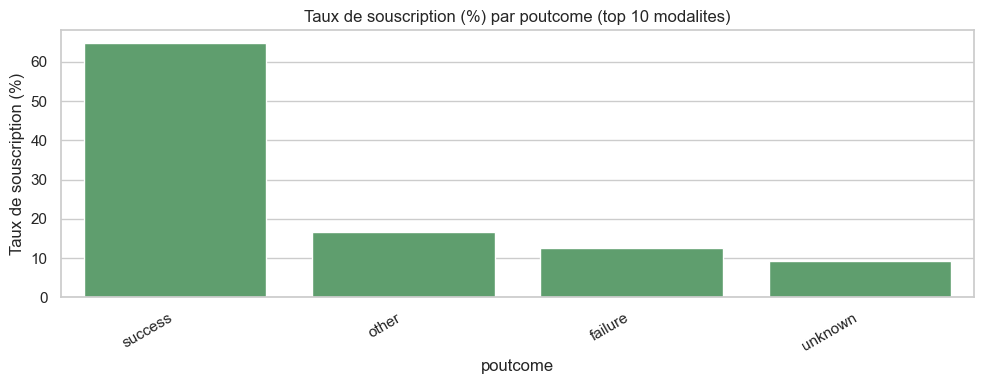


Resume des variables numeriques selon la cible y:


age                              balance                                          day                          \
     count   mean median    std min max   count     mean median     std   min     max  count   mean median   std min   
y                                                                                                                      
no   39922  40.84   39.0  10.17  18  95   39922  1303.71  417.0  2974.2 -8019  102127  39922  15.89   16.0  8.29   1   
yes   5289  41.67   38.0  13.50  18  95    5289  1804.27  733.0  3501.1 -3058   81204   5289  15.16   15.0  8.50   1   

        duration                                  campaign                             pdays                        \
    max    count    mean median     std min   max    count  mean median   std min max  count   mean median     std   
y                                                                                                                    
no   31    39922  221.18  164.0  207.38   0  4918    39922  2.85    2.0  3.21   1  63  39922  36.42   -1.0   96.76   
yes  31     5289  537.29  426.0  392.53   8  3881     5289  2.14    2.0  1.92   1  32   5289  68.70   -1.0  118.82   

             previous                              
    min  max    count  mean median   std min  max  
y                                                  
no   -1  871    39922  0.50    0.0  2.26   0  275  
yes  -1  854     5289  1.17    0.0  2.55   0   58


Matrice de correlation (Spearman) - variables numeriques:


,age,balance,day,duration,campaign,pdays,previous
age,1.00,0.10,-0.01,-0.03,0.04,-0.02,-0.01
balance,0.10,1.00,0.00,0.04,-0.03,0.07,0.08
day,-0.01,0.00,1.00,-0.06,0.14,-0.09,-0.09
duration,-0.03,0.04,-0.06,1.00,-0.11,0.03,0.03
campaign,0.04,-0.03,0.14,-0.11,1.00,-0.11,-0.11
pdays,-0.02,0.07,-0.09,0.03,-0.11,1.00,0.99
previous,-0.01,0.08,-0.09,0.03,-0.11,0.99,1.00


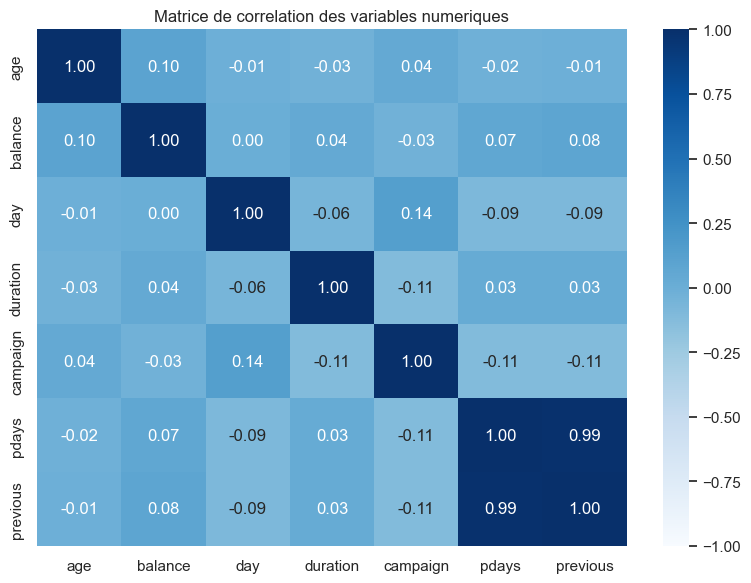

In [6]:
# 2.3 Relations entre variables explicatives et la cible y (toutes les colonnes)

cat_cols_all = [c for c in df.select_dtypes(include=["object"]).columns if c != "y"]
num_cols_all = [c for c in df.select_dtypes(include=["number"]).columns if c != "y_bin"]

df_rate = df.copy()
df_rate["y_bin"] = (df_rate["y"] == "yes").astype(int)

# Taux de souscription par modalite pour toutes les variables categorielles
for col in cat_cols_all:
    tmp = (
        df_rate.groupby(col, as_index=False)
        .agg(n_clients=("y_bin", "size"), taux_souscription=("y_bin", "mean"))
        .sort_values("taux_souscription", ascending=False)
    )
    tmp["taux_souscription"] = (tmp["taux_souscription"] * 100).round(2)
    print(f"\nTaux de souscription par {col}:")
    display(tmp)

    # Graphique des modalites les plus frequentes pour une lecture claire
    top_modalites = df[col].value_counts().head(10).index
    plot_df = tmp[tmp[col].isin(top_modalites)].sort_values("taux_souscription", ascending=False)

    plt.figure(figsize=(10, 4))
    sns.barplot(data=plot_df, x=col, y="taux_souscription", color="#55A868")
    plt.title(f"Taux de souscription (%) par {col} (top 10 modalites)")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Taux de souscription (%)")
    plt.tight_layout()
    plt.show()

# Resume tabulaire des variables numeriques selon y
num_vs_target = (
    df.groupby("y")[num_cols_all]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

print("\nResume des variables numeriques selon la cible y:")
display(num_vs_target)

# Matrice de correlation des variables numeriques
corr_num = df[num_cols_all].corr(method="spearman").round(2)
print("\nMatrice de correlation (Spearman) - variables numeriques:")
display(corr_num)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_num, annot=True, cmap="Blues", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matrice de correlation des variables numeriques")
plt.tight_layout()
plt.show()

In [7]:
# Retirer pdays (multicolinearite avec previous, r=0.99) - garder previous
df = df.drop(columns=["pdays"])
print("Colonne pdays retiree" )

Colonne pdays retiree


In [5]:
# 2.4 Tests statistiques (inference) - variables categorielles
from scipy.stats import chi2_contingency

cat_test_cols = [c for c in df.select_dtypes(include=["object"]).columns if c != "y"]

# Variables categorielles vs y : test du Chi2
chi2_results = []

for col in cat_test_cols:
    contingency = pd.crosstab(df[col], df["y"])
    chi2, p_value, dof, _ = chi2_contingency(contingency)
    chi2_results.append({
        "variable": col,
        "chi2": chi2,
        "dof": dof,
        "p_value": p_value,
        "significatif_5pct": p_value < 0.05
    })

chi2_table = pd.DataFrame(chi2_results).sort_values("p_value")
print("Resultats Chi2 (toutes variables categorielles vs y):")
display(chi2_table)





Resultats Chi2 (toutes variables categorielles vs y):


,variable,chi2,dof,p_value,significatif_5pct
6,month,3061.838938,11,0.000000e+00,True
7,poutcome,4391.506589,3,0.000000e+00,True
4,housing,874.822449,1,2.918798e-192,True
0,job,830.547238,10,5.575428e-172,True
2,education,223.834823,2,2.482480e-49,True
5,loan,209.616980,1,1.665061e-47,True
1,marital,196.495946,2,2.145100e-43,True
3,default,22.202250,1,2.453861e-06,True


## 3. Modelisation statistique - Regression logistique


In [ ]:
# 3.1 Imports et selection des variables
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import statsmodels.api as sm

# Variables sur toutes les colonnes (hors cible)
all_cat = [c for c in df.select_dtypes(include=["object"]).columns if c != "y"]
all_num = [c for c in df.select_dtypes(include=["number"]).columns if c != "y_bin"]

# Selection des variables significatives 
if "chi2_table" in globals() and not chi2_table.empty:
    sig_cat_phase2 = chi2_table.loc[chi2_table["significatif_5pct"], "variable"].tolist()
else:
    sig_cat_phase2 = []

selected_cat = [c for c in all_cat if c in sig_cat_phase2] or all_cat
selected_num = all_num.copy()

INCLUDE_DURATION = False 
if not INCLUDE_DURATION and "duration" in selected_num:
    selected_num.remove("duration")

print("Variables categorielles retenues:", selected_cat)
print("Variables numeriques retenues:", selected_num)

# Cible binaire
df_model = df.copy()
df_model["y_bin"] = (df_model["y"] == "yes").astype(int)


Variables categorielles retenues: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'month', 'poutcome']
Variables numeriques retenues: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']


In [17]:

log_candidates = ["balance", "duration", "campaign", "previous"]
log_cols = [c for c in log_candidates if c in df_model.columns and df_model[c].min() >= 0]
for col in log_cols:
    df_model[col] = np.log1p(df_model[col])
print("Variables transformees (log1p):", log_cols)

Variables transformees (log1p): ['duration', 'campaign', 'previous']


In [18]:
# 3.2 Fonction d'entrainement et evaluation du modele logistique
def run_logistic_model(data, cat_vars, num_vars, model_name):
    feature_cols = cat_vars + num_vars
    X = data[feature_cols].copy()
    y = data["y_bin"].copy()

    # Nettoyer inf/nan (evite ValueError sklearn)
    X = X.replace([np.inf, -np.inf], np.nan)
    for col in X.select_dtypes(include=[np.number]).columns:
        X[col] = X[col].fillna(X[col].median())

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Exclure colonnes numeriques a variance nulle (evite division par zero dans RobustScaler)
    num_vars_ok = [c for c in num_vars if c in X_train.columns and X_train[c].std() > 1e-10]

    transformers = []
    if num_vars_ok:
        transformers.append(("num", RobustScaler(), num_vars_ok))
    if cat_vars:
        transformers.append(("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_vars))

    preprocessor = ColumnTransformer(transformers=transformers)

    clf = Pipeline(
        steps=[
            ("prep", preprocessor),
            ("logit", LogisticRegression(max_iter=2000)),
        ]
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    perf = {
        "model": model_name,
        "accuracy": round(accuracy_score(y_test, y_pred), 4),
        "precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "f1": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "roc_auc": round(roc_auc_score(y_test, y_proba), 4),
    }

    cm = confusion_matrix(y_test, y_pred)

    # Modele statistique pour interpretation (odds ratios + p-values)
    X_sm = pd.get_dummies(X, columns=cat_vars, drop_first=True)
    X_sm = sm.add_constant(X_sm, has_constant="add").astype(float)

    try:
        sm_model = sm.Logit(y, X_sm).fit(disp=False, maxiter=200)
        coef_table = pd.DataFrame({
            "coef": sm_model.params,
            "odds_ratio": np.exp(sm_model.params),
            "p_value": sm_model.pvalues,
        }).sort_values("p_value")
    except Exception as e:
        coef_table = pd.DataFrame({
            "coef": [np.nan],
            "odds_ratio": [np.nan],
            "p_value": [np.nan]
        }, index=[f"statsmodels_error: {e}"])

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_roc = roc_auc_score(y_test, y_proba)
    return perf, cm, coef_table, (fpr, tpr, auc_roc)


Performances


,model,accuracy,precision,recall,f1,roc_auc
0,Logit,0.7641,0.2706,0.5992,0.3728,0.7518


Matrice de confusion


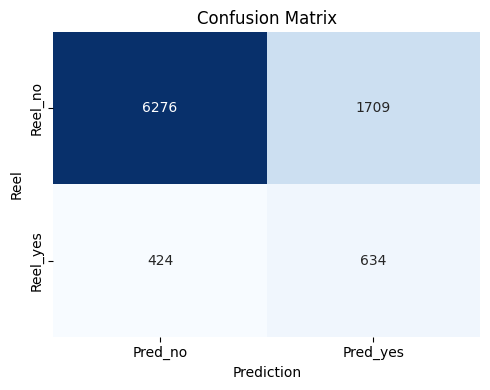

In [19]:
cat_vars_a = selected_cat.copy()
num_vars_a = selected_num.copy()

perf_a, cm_a, coef_a, roc_logit = run_logistic_model(
    data=df_model,
    cat_vars=cat_vars_a,
    num_vars=num_vars_a,
    model_name="Logit"
)

print("Performances")
display(pd.DataFrame([perf_a]))

print("Matrice de confusion")
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_a,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Pred_no", "Pred_yes"],
    yticklabels=["Reel_no", "Reel_yes"]
)
plt.xlabel("Prediction")
plt.ylabel("Reel")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


## 4. Modeles de classification 


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
PRIORITY_METRIC = "recall" 
INCLUDE_DURATION = False     

# Variables sur toutes les colonnes (hors cible)
cat_vars_ml = [c for c in df.select_dtypes(include=["object"]).columns if c != "y"]
num_vars_ml = [c for c in df.select_dtypes(include=["number"]).columns if c != "y_bin"]

if not INCLUDE_DURATION and "duration" in num_vars_ml:
    num_vars_ml.remove("duration")

feature_cols_ml = cat_vars_ml + num_vars_ml

# Cible binaire
df_ml = df.copy()
df_ml["y_bin"] = (df_ml["y"] == "yes").astype(int)

X = df_ml[feature_cols_ml]
y = df_ml["y_bin"]

# Split train/validation/test: 80/10/10 (stratifie)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

# Desequilibre de classes
class_counts = y.value_counts().sort_index()
imbalance_table = pd.DataFrame({
    "classe": [0, 1],
    "label": ["no", "yes"],
    "count": [class_counts.get(0, 0), class_counts.get(1, 0)],
    "pct": [round(class_counts.get(0, 0) / len(y) * 100, 2), round(class_counts.get(1, 0) / len(y) * 100, 2)]
})

print("Nb variables categorielles:", len(cat_vars_ml), "| Nb variables numeriques:", len(num_vars_ml))
print("Variables utilisees (ML):", feature_cols_ml)
print("Shapes -> train:", X_train.shape, "valid:", X_valid.shape, "test:", X_test.shape)
print("\nDistribution de la cible (desequilibre):")
display(imbalance_table)

# Preprocessing commun
transformers_ml = []
if num_vars_ml:
    transformers_ml.append(("num", RobustScaler(), num_vars_ml))
if cat_vars_ml:
    transformers_ml.append(("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_vars_ml))

preprocessor_ml = ColumnTransformer(transformers=transformers_ml)

# SMOTE pour traiter le desequilibre de classes (oversampling)
USE_SMOTE = True
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    smote_available = True
except ImportError:
    smote_available = False
    print("imbalanced-learn non installe. SMOTE desactive. pip install imbalanced-learn")

smote_step = ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5, sampling_strategy="auto")) if (USE_SMOTE and smote_available) else None
print("SMOTE:", "active" if smote_step else "desactive")

# Afficher que les donnees sont balancees apres SMOTE
if smote_step is not None:
    X_train_prep = preprocessor_ml.fit_transform(X_train)
    X_bal, y_bal = SMOTE(random_state=RANDOM_STATE, k_neighbors=5, sampling_strategy="auto").fit_resample(X_train_prep, y_train)
    bal_counts = pd.Series(y_bal).value_counts().sort_index()
    print("\nDonnees d'entrainement balancees (apres SMOTE):")
    print(f"  Classe 0 (no):  {bal_counts.get(0, 0):,} ({100*bal_counts.get(0,0)/len(y_bal):.1f}%)")
    print(f"  Classe 1 (yes): {bal_counts.get(1, 0):,} ({100*bal_counts.get(1,0)/len(y_bal):.1f}%)")

Nb variables categorielles: 8 | Nb variables numeriques: 6
Variables utilisees (ML): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'month', 'poutcome', 'age', 'balance', 'day', 'campaign', 'pdays', 'previous']
Shapes -> train: (36168, 14) valid: (4521, 14) test: (4522, 14)

Distribution de la cible (desequilibre):


,classe,label,count,pct
0,0,no,39922,88.3
1,1,yes,5289,11.7


SMOTE: active

Donnees d'entrainement balancees (apres SMOTE):
  Classe 0 (no):  31,937 (50.0%)
  Classe 1 (yes): 31,937 (50.0%)


In [21]:

from xgboost import XGBClassifier

xgb_available = True

models = {
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

if xgb_available:
    models["XGBoost"] = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

fitted_pipelines = {}
rows_valid = []
rows_test = []

for model_name, estimator in models.items():
    steps = [("prep", preprocessor_ml)]
    if smote_step is not None:
        steps.append(smote_step)
    steps.append(("model", estimator))
    pipe = ImbPipeline(steps=steps) if smote_step else Pipeline(steps=steps)
    pipe.fit(X_train, y_train)
    fitted_pipelines[model_name] = pipe

    # Validation
    pred_valid = pipe.predict(X_valid)
    proba_valid = pipe.predict_proba(X_valid)[:, 1]
    rows_valid.append({
        "model": model_name,
        "accuracy": accuracy_score(y_valid, pred_valid),
        "precision": precision_score(y_valid, pred_valid, zero_division=0),
        "recall": recall_score(y_valid, pred_valid, zero_division=0),
        "f1": f1_score(y_valid, pred_valid, zero_division=0),
        "roc_auc": roc_auc_score(y_valid, proba_valid),
    })

    # Test
    pred_test = pipe.predict(X_test)
    proba_test = pipe.predict_proba(X_test)[:, 1]
    rows_test.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, pred_test),
        "precision": precision_score(y_test, pred_test, zero_division=0),
        "recall": recall_score(y_test, pred_test, zero_division=0),
        "f1": f1_score(y_test, pred_test, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba_test),
    })

valid_results = pd.DataFrame(rows_valid).sort_values(PRIORITY_METRIC, ascending=False)
test_results = pd.DataFrame(rows_test)

for col in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    valid_results[col] = valid_results[col].round(4)
    test_results[col] = test_results[col].round(4)

print(f"Classement des modeles (validation) selon la metrique prioritaire: {PRIORITY_METRIC}")
display(valid_results)

print("\nPerformances sur jeu de test:")
display(test_results.sort_values(PRIORITY_METRIC, ascending=False))

best_model_name = valid_results.iloc[0]["model"]
best_model = fitted_pipelines[best_model_name]
print(f"\nMeilleur modele retenu (selon {PRIORITY_METRIC} en validation): {best_model_name}")

Classement des modeles (validation) selon la metrique prioritaire: recall


,model,accuracy,precision,recall,f1,roc_auc
2,XGBoost,0.5881,0.1919,0.7845,0.3083,0.7622
0,DecisionTree,0.8160,0.2795,0.3629,0.3158,0.6195
1,RandomForest,0.8837,0.5048,0.3006,0.3768,0.7580



Performances sur jeu de test:


,model,accuracy,precision,recall,f1,roc_auc
2,XGBoost,0.5798,0.1886,0.7845,0.3040,0.7731
0,DecisionTree,0.8149,0.2735,0.3516,0.3077,0.6139
1,RandomForest,0.8910,0.5652,0.2949,0.3876,0.7762



Meilleur modele retenu (selon recall en validation): XGBoost


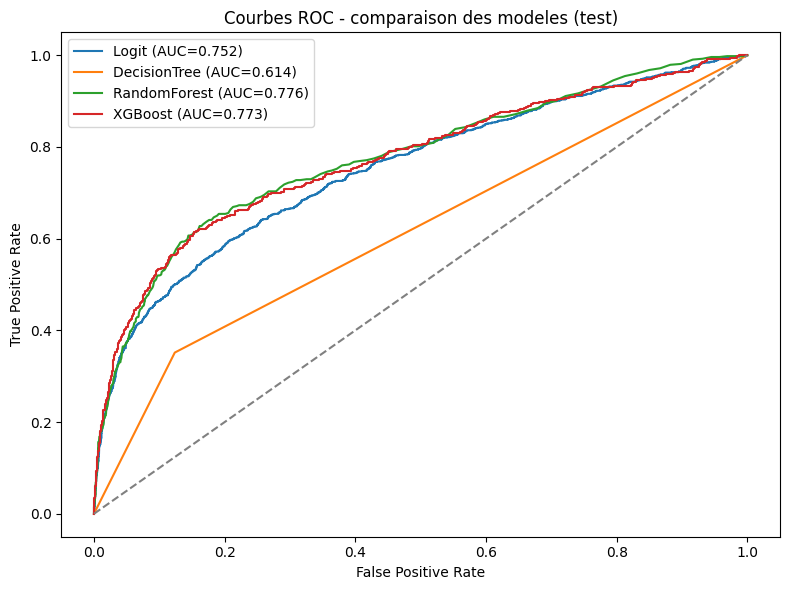

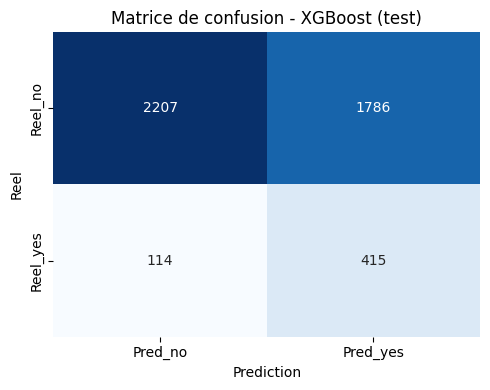

In [22]:
# 4.3 Visualisations: courbes ROC + matrice de confusion du meilleur modele

plt.figure(figsize=(8, 6))
# Courbe ROC Logit (section 3)
if "roc_logit" in globals():
    fpr_l, tpr_l, auc_l = roc_logit
    plt.plot(fpr_l, tpr_l, label=f"Logit (AUC={auc_l:.3f})")
for model_name, pipe in fitted_pipelines.items():
    proba_test = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba_test)
    auc_val = roc_auc_score(y_test, proba_test)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_val:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbes ROC - comparaison des modeles (test)")
plt.legend()
plt.tight_layout()
plt.show()

# Matrice de confusion du meilleur modele
best_pred_test = best_model.predict(X_test)
best_cm = confusion_matrix(y_test, best_pred_test)

plt.figure(figsize=(5, 4))
sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Pred_no", "Pred_yes"],
    yticklabels=["Reel_no", "Reel_yes"]
)
plt.xlabel("Prediction")
plt.ylabel("Reel")
plt.title(f"Matrice de confusion - {best_model_name} (test)")
plt.tight_layout()
plt.show()